## Step 1: Load the documents with the help of the pypdf loader.

In [1]:
from langchain_community.document_loaders import PyPDFLoader

C:\Users\rajen\AppData\Local\Temp\ipykernel_10352\4175148793.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [2]:
loader = PyPDFLoader(file_path='intro-to-ml.pdf')

In [7]:
documents = loader.load()

In [10]:
len(documents) # per page one document

392

## Step 2: split the docs into the chunks.

In [11]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [14]:
splitter = RecursiveCharacterTextSplitter(chunk_size = 1000,chunk_overlap = 200)
chunks = splitter.split_documents(documents=documents)

In [15]:
len(chunks)

973

## Step 3: convert the chunk documents into the embeddings and store them in a vector store

In [26]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [27]:
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS

In [28]:
vector_store = FAISS.from_documents(
    documents=chunks,
    embedding=OpenAIEmbeddings(model="text-embedding-3-small")
)

## Create one retriever based on similarity search that will fetch the relevent docs.


In [29]:
retriever = vector_store.as_retriever(
    search_type ='similarity',search_kwargs={'k':5}
)

## Create one rag tool that will fetch the relevent document using retreiver.

In [30]:
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode,tools_condition

In [31]:
@tool
def rag_tool(query):
    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(input=query)

    context =[doc.page_content for doc in result]

    metadata = [doc.metadata for doc in result]

    return {
        'query':query,
        'context':context,
        'metadata':metadata
    }

## Create a llm and bind it will tool

In [32]:
from langchain_openai import ChatOpenAI

In [33]:
llm = ChatOpenAI(model = 'gpt-4o-mini')

In [34]:
llm_with_tools = llm.bind_tools(tools=[rag_tool])

## Now create the workflow and call the llm_with_tools with the help of tool_condition

In [52]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal,Annotated
from langchain_core.messages import BaseMessage,HumanMessage,AIMessage
from langgraph.graph.message import add_messages


In [53]:
class ChatState(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [54]:
def chat_node(state: ChatState):
    messages = state['messages']

    response = llm_with_tools.invoke(messages)

    return {'messages':[response]}

In [56]:
graph = StateGraph(state_schema = ChatState)
graph.add_node('chat_node',chat_node)
graph.add_node('tool_node',ToolNode(tools=[rag_tool]))

graph.add_edge(START,'chat_node')
graph.add_conditional_edges('chat_node',tools_condition,{'tools':'tool_node','__end__':END})
graph.add_edge('tool_node','chat_node')

chatbot = graph.compile()

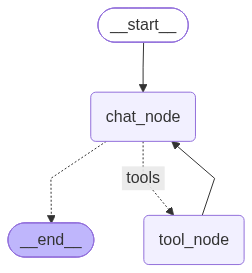

In [57]:
chatbot

In [58]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "Using the pdf notes, explain how to find the ideal value of K in KNN"
                )
            )
        ]
    }
)

In [60]:
print(result['messages'][-1].content)

To find the ideal value of K in the k-nearest neighbors (KNN) algorithm, the following considerations are essential:

1. **Understanding K**: The parameter \( K \) signifies the number of nearest neighbors considered when making a prediction. Instead of relying on just the closest neighbor, KNN can use a fixed number \( K \) of neighbors (like 3 or 5), and the prediction is made based on the majority vote of these neighbors.

2. **Impact of K Value**: 
   - A small value of \( K \) (like 1) can lead to sensitive predictions that may fit closely to the training data but can be very noisy and unstable. Such models might overfit the training data.
   - Conversely, a larger value of \( K \) can smooth out the predictions and make them more robust, but this may also lead to underfitting if \( K \) is too large since it averages over potentially irrelevant data.

3. **Choosing the Right K**: There's no one-size-fits-all answer for the ideal value of \( K \). Common practices include:
   - Te